# Overall — combine the four states

This is the **overall maths**: it runs all four kinematic axes on the same window and
stacks them into one read of *what the person is doing* — plus the context the heart
signal needs.

## What goes in
A 5 s window of accelerometer data (PAMAP2 hand + chest). From it we compute the four axes:

| axis | question | sensor | possible values |
|---|---|---|---|
| **activity** | how hard? | hand | sedentary / moderate / vigorous |
| **regularity** | how smooth? | hand | calm / rhythmic / erratic |
| **posture** | which way is down? | chest (+ standing calib.) | lying / upright / in motion |
| **locomotion** | moving through space? | hand | stationary / on foot / in vehicle |

## What comes out
The four are concatenated into **one situation**, an **exertion score (0–3)**, and a **heart-rate note**.

**The six situations — and which axes decide each** (checked top to bottom):

| situation | fires when |
|---|---|
| **resting (lying)** | posture = *lying* |
| **walking** | locomotion = *on foot*, activity ≠ vigorous |
| **running** | locomotion = *on foot*, activity = *vigorous* |
| **in vehicle** | locomotion = *in vehicle* |
| **restless** | stationary + upright + *erratic* |
| **still** | stationary + upright + calm  (the default) |

**Exertion (0–3):** still / resting / in-vehicle = 0, walking = 2, running = 3.
**Heart note:** exertion ≥ 2 → *HR rise is physical (expected)*; still + erratic → *HR rise may be stress*; else *calm baseline*.

## The flow
```
5 s window (hand + chest)
  → activity, regularity, posture, locomotion     (the four axes — the ingredients)
  → situation + exertion + heart note              (the combined read)
```

The four axes are the ingredients; this notebook is the read on top of them.

In [ ]:
import numpy as np

# --- the four axes, each a tiny deterministic rule ---
def hand_feats(w):                       # movement + repeat-rhythm from |accel| (orientation-proof)
    mag = np.sqrt((w**2).sum(axis=1))
    m = mag - mag.mean(); ac = np.correlate(m, m, mode="full")[len(m)-1:]
    rhythm = 0.0 if ac[0] == 0 else (ac/ac[0])[15:128].max()
    return mag.std(), float(rhythm)

def activity_state(movement):            # how hard
    if movement < 0.5: return "sedentary"
    if movement < 7:   return "moderate"
    return "vigorous"

def movement_regularity(movement, rhythm):   # how smooth
    if movement < 1.0: return "calm"
    return "rhythmic" if rhythm > 0.40 else "erratic"

def locomotion(movement, rhythm):        # moving through space?
    if movement < 0.3: return "stationary"
    return "on foot" if rhythm > 0.30 else "in vehicle"

def posture(chest_w, up):                # which way is down (chest + standing calibration)
    if np.sqrt((chest_w**2).sum(axis=1)).std() > 1.0: return "in motion"
    g = chest_w.mean(axis=0)
    tilt = np.degrees(np.arccos(np.clip(g @ up / (np.linalg.norm(g)*np.linalg.norm(up)+1e-9), -1, 1)))
    return "upright" if tilt < 45 else "lying"

# --- concatenate the four -> one situation + an exertion score + a heart-rate note ---
def situation(act, reg, pos, loco):              # checked top to bottom
    if pos == "lying":        return "resting (lying)"   # lying is a reliable cue -> trust it first
    if loco == "on foot":     return "running" if act == "vigorous" else "walking"
    if loco == "in vehicle":  return "in vehicle"
    if reg == "erratic":      return "restless"
    return "still"

LOAD = {"sedentary": 0, "moderate": 2, "vigorous": 3}
def exertion(act, loco):                 # 0-3 physical load (vehicle = passive = 0)
    return 0 if loco == "in vehicle" else LOAD[act]

def heart_note(score, reg):              # how to read a heart-rate change in this context
    if score >= 2:       return "HR rise = physical exertion (expected)"
    if reg == "erratic": return "still but restless -> HR rise may be stress"
    return "calm baseline"

## Run all four on the data

PAMAP2 has hand + chest synced, so we compute all four axes from the *same* window:
hand → activity / regularity / locomotion, chest → posture (per-subject standing
calibration). Protocol + Optional (for driving). Then concatenate → one situation.

In [2]:
import pandas as pd, glob, re

BASE  = "/home/voare/Documents/Synheart/Kinematics/Dataset/PAMAP2_data/PAMAP2_Dataset"
PROTO = sorted(glob.glob(BASE+"/Protocol/*.dat"))
OPT   = sorted(glob.glob(BASE+"/Optional/*.dat"))
NAMES = {1:"lying",2:"sitting",3:"standing",4:"walking",5:"running",
         7:"nordic_walk",11:"driving",12:"ascend_stairs",13:"descend_stairs"}
WIN = 500

# posture calibration: standing-gravity per subject (from Protocol), global fallback
subj_up = {}
for p in PROTO:
    sid = int(re.search(r"subject(\d+)", p).group(1))
    st = pd.read_csv(p, sep=r"\s+", header=None)
    st = st[st[1]==3][[21,22,23]].interpolate().to_numpy(); st = st[~np.isnan(st).any(1)]
    if len(st): subj_up[sid] = st.mean(0)
global_up = np.mean(list(subj_up.values()), axis=0)

rows = []
for p in PROTO + OPT:
    sid = int(re.search(r"subject(\d+)", p).group(1)); up = subj_up.get(sid, global_up)
    d = pd.read_csv(p, sep=r"\s+", header=None); act = d[1].to_numpy()
    hand = d[[4,5,6]].to_numpy(); chest = d[[21,22,23]].to_numpy()
    ch = np.where(np.diff(act) != 0)[0] + 1
    for s0, e0 in zip(np.r_[0, ch], np.r_[ch, len(act)]):
        if act[s0] not in NAMES: continue
        for s in range(s0, e0 - WIN + 1, WIN):
            hw, cw = hand[s:s+WIN], chest[s:s+WIN]
            if np.isnan(hw).any() or np.isnan(cw).any(): continue
            mv, rg = hand_feats(hw)
            a  = activity_state(mv); r = movement_regularity(mv, rg)
            lo = locomotion(mv, rg); ps = posture(cw, up)
            sit = situation(a, r, ps, lo); sc = exertion(a, lo)
            rows.append((NAMES[act[s0]], a, r, ps, lo, sit, sc, heart_note(sc, r)))

res = pd.DataFrame(rows, columns=["activity","activity_state","regularity",
                                  "posture","locomotion","situation","exertion","heart_note"])
print("windows:", len(res))
print(res.situation.value_counts().to_string())
res.head()

windows: 1645
situation
still              446
in vehicle         396
walking            375
resting (lying)    314
running            114


,activity,activity_state,regularity,posture,locomotion,situation,exertion,heart_note
0,lying,moderate,calm,upright,in vehicle,in vehicle,0,calm baseline
1,lying,moderate,erratic,upright,in vehicle,in vehicle,0,still but restless -> HR rise may be stress
2,lying,moderate,calm,lying,in vehicle,in vehicle,0,calm baseline
3,lying,sedentary,calm,lying,stationary,resting (lying),0,calm baseline
4,lying,sedentary,calm,lying,in vehicle,in vehicle,0,calm baseline


## Does the combined read match reality?

Map each real activity to the situation it should produce, and compare. The diagonal
is correct. The combined read is only as strong as its weakest ingredient — so the
leak to watch is the locomotion catch-all ("in vehicle").

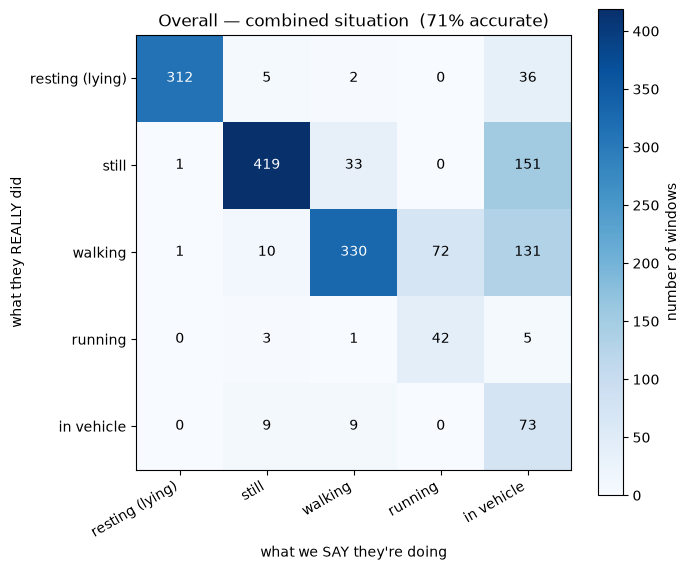

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

expected = {"lying":"resting (lying)", "sitting":"still", "standing":"still",
            "walking":"walking", "nordic_walk":"walking", "ascend_stairs":"walking",
            "descend_stairs":"walking", "running":"running", "driving":"in vehicle"}
res["true"] = res.activity.map(expected)

labels = ["resting (lying)", "still", "walking", "running", "in vehicle"]
cm  = confusion_matrix(res["true"], res["situation"], labels=labels)
acc = (res["true"] == res["situation"]).mean()

plt.figure(figsize=(7,6))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(5), labels, rotation=30, ha="right"); plt.yticks(range(5), labels)
plt.xlabel("what we SAY they're doing")   # x = combined situation
plt.ylabel("what they REALLY did")        # y = true activity
for i in range(5):
    for j in range(5):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(label="number of windows")
plt.title(f"Overall — combined situation  ({acc*100:.0f}% accurate)")
plt.tight_layout(); plt.show()





The point of stacking the states: the *same* heart-rate change means different things
in different situations. One example window per situation, read end to end — the four
axes, then what they add up to:

In [4]:
for sit in ["resting (lying)", "still", "walking", "running", "in vehicle", "restless"]:
    g = res[res.situation == sit]
    if len(g):
        r = g.iloc[0]
        print(f"[{sit:16s}] act={r.activity_state:9s} reg={r.regularity:8s} "
              f"pos={r.posture:9s} loco={r.locomotion:10s} -> exertion={r.exertion}  |  {r.heart_note}")

[resting (lying) ] act=sedentary reg=calm     pos=lying     loco=stationary -> exertion=0  |  calm baseline
[still           ] act=sedentary reg=calm     pos=upright   loco=stationary -> exertion=0  |  calm baseline
[walking         ] act=moderate  reg=erratic  pos=upright   loco=on foot    -> exertion=2  |  HR rise = physical exertion (expected)
[running         ] act=vigorous  reg=erratic  pos=in motion loco=on foot    -> exertion=3  |  HR rise = physical exertion (expected)
[in vehicle      ] act=moderate  reg=calm     pos=upright   loco=in vehicle -> exertion=0  |  calm baseline
